In [4]:
%pip install pandas numpy matplotlib statsmodels

Note: you may need to restart the kernel to use updated packages.


In [5]:
#inmports and settings
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import Holt
from statsmodels.tools.sm_exceptions import ConvergenceWarning

DATA_DIR = Path(
    "/Users/elenachen/Desktop/"
    "Environment_LivestockManure_E_All_Data_(Normalized)"
)

DATA_FILE = (
    DATA_DIR
    / "Environment_LivestockManure_E_All_Data_(Normalized).csv"
)

# Change to an exact country name if needed.
AREA = "World"

ANIMALS = ["Sheep and Goats", "Chickens", "Cattle"]

ELEMENT = "Amount excreted in manure (N content)"

START_YEAR = 2013
END_YEAR = 2023
FORECAST_END = 2033

MODELS = ["Linear", "Holt damped", "Log-linear"]

assert DATA_FILE.exists(), f"File not found: {DATA_FILE}"

In [6]:
#This keeps all 11 years, not just the two endpoints. 
#Using World avoids double-counting countries and regional aggregates.
parts = []

for chunk in pd.read_csv(
    DATA_FILE,
    usecols=["Area", "Item", "Element", "Year", "Unit", "Value"],
    chunksize=250_000,
):
    mask = (
        chunk["Area"].eq(AREA)
        & chunk["Item"].isin(ANIMALS)
        & chunk["Element"].eq(ELEMENT)
        & chunk["Year"].between(START_YEAR, END_YEAR)
    )

    parts.append(chunk.loc[mask].copy())

data = pd.concat(parts, ignore_index=True)

if data.empty:
    raise ValueError(f"No matching data found for {AREA!r}.")

data["Value"] = pd.to_numeric(data["Value"], errors="coerce")

if data["Value"].isna().any():
    raise ValueError("Missing or invalid nitrogen values.")

if not data["Unit"].eq("kg").all():
    raise ValueError("Unexpected units. Inspect the Unit column.")

if data.duplicated(["Item", "Year"]).any():
    raise ValueError("Duplicate animal–year records found.")

historical = (
    data.pivot(index="Year", columns="Item", values="Value")
    .reindex(
        index=range(START_YEAR, END_YEAR + 1),
        columns=ANIMALS,
    )
    / 1e9
)

if historical.isna().any().any():
    raise ValueError("Some required animal–year observations are missing.")

if (historical <= 0).any().any():
    raise ValueError("Log-linear modeling requires positive observations.")

print("Units: billion kg N/year")
display(historical.round(3))

Units: billion kg N/year


Item,Sheep and Goats,Chickens,Cattle
Year,,,
2013,29.413,8.814,60.702
2014,29.612,8.914,61.210
2015,30.213,9.206,61.468
2016,30.717,9.507,62.196
2017,31.110,10.276,62.389
2018,31.357,10.191,62.675
2019,32.204,10.474,63.279
2020,32.803,10.856,64.213
2021,33.227,10.594,64.793


In [9]:
#Define three models
def fit_model(years, values, model_name):
    years = np.asarray(years, dtype=int)
    values = np.asarray(values, dtype=float)

    x = years - START_YEAR

    if model_name == "Linear":
        slope, intercept = np.polyfit(x, values, 1)

        return {
            "name": model_name,
            "intercept": intercept,
            "slope": slope,
        }

    if model_name == "Log-linear":
        slope, intercept = np.polyfit(x, np.log(values), 1)

        residuals = np.log(values) - (intercept + slope * x)

        # Adjust when transforming predictions back from log units.
        correction = np.mean(np.exp(residuals))

        return {
            "name": model_name,
            "intercept": intercept,
            "slope": slope,
            "correction": correction,
        }

    if model_name == "Holt damped":
        if len(values) < 2:
            raise ValueError("Holt requires at least two observations.")

        initial_level = float(values[0])
        initial_trend = float(values[1] - values[0])

        with warnings.catch_warnings():
            warnings.simplefilter("error", ConvergenceWarning)

            result = Holt(
                values,
                damped_trend=True,
                initialization_method="known",
                initial_level=initial_level,
                initial_trend=initial_trend,
            ).fit(optimized=True)

        return {
            "name": model_name,
            "result": result,
            "last_year": int(years[-1]),
        }

    raise ValueError(f"Unknown model: {model_name}")


def predict_model(fitted, years):
    years = np.asarray(years, dtype=int)
    x = years - START_YEAR

    if fitted["name"] == "Linear":
        prediction = fitted["intercept"] + fitted["slope"] * x

    elif fitted["name"] == "Log-linear":
        prediction = (
            np.exp(fitted["intercept"] + fitted["slope"] * x)
            * fitted["correction"]
        )

    elif fitted["name"] == "Holt damped":
        horizons = years - fitted["last_year"]

        if np.any(horizons < 1):
            raise ValueError("Holt predictions must be after training ends.")

        full_forecast = np.asarray(
            fitted["result"].forecast(int(horizons.max()))
        )

        prediction = full_forecast[horizons - 1]

    else:
        raise ValueError("Unknown fitted model.")

    if not np.isfinite(prediction).all():
        raise ValueError("Model produced non-finite predictions.")

    return np.maximum(prediction, 0)

In [10]:
#For each model:
#Train through 2018 → predict 2019–2021.
#Train through 2019 → predict 2020–2022.
#Train through 2020 → predict 2021–2023.
#The overlapping forecasts are intentional: they test different forecast starting points.
TRAIN_END_YEARS = [2018, 2019, 2020]
VALIDATION_HORIZON = 3

validation_rows = []
failures = []

for animal in ANIMALS:
    for model_name in MODELS:
        for train_end in TRAIN_END_YEARS:
            train = historical.loc[START_YEAR:train_end, animal]

            test_years = np.arange(
                train_end + 1,
                train_end + VALIDATION_HORIZON + 1,
            )

            actual = historical.loc[test_years, animal].to_numpy()

            try:
                fitted = fit_model(
                    train.index,
                    train.to_numpy(),
                    model_name,
                )

                predictions = predict_model(fitted, test_years)

                for year, observed, predicted in zip(
                    test_years, actual, predictions
                ):
                    validation_rows.append({
                        "Animal": animal,
                        "Model": model_name,
                        "Training end": train_end,
                        "Forecast year": int(year),
                        "Horizon": int(year - train_end),
                        "Actual": observed,
                        "Predicted": predicted,
                    })

            except Exception as error:
                failures.append({
                    "Animal": animal,
                    "Model": model_name,
                    "Training end": train_end,
                    "Error": str(error),
                })

validation_predictions = pd.DataFrame(validation_rows)

if failures:
    print("Some fits failed; affected models cannot win unless all folds succeed.")
    display(pd.DataFrame(failures))

display(validation_predictions.head())

,Animal,Model,Training end,Forecast year,Horizon,Actual,Predicted
0,Sheep and Goats,Linear,2018,2019,1,32.203774,31.875692
1,Sheep and Goats,Linear,2018,2020,2,32.803166,32.296241
2,Sheep and Goats,Linear,2018,2021,3,33.227055,32.716790
3,Sheep and Goats,Linear,2019,2020,1,32.803166,32.483716
4,Sheep and Goats,Linear,2019,2021,2,33.227055,32.939417


In [12]:
#Compare forecast errors
errors = validation_predictions.copy()

errors["Absolute error"] = (
    errors["Actual"] - errors["Predicted"]
).abs()

errors["Squared error"] = (
    errors["Actual"] - errors["Predicted"]
) ** 2

errors["Absolute percentage error"] = (
    errors["Absolute error"] / errors["Actual"] * 100
)

scores = (
    errors.groupby(["Animal", "Model"], as_index=False)
    .agg(
        MAE=("Absolute error", "mean"),
        MSE=("Squared error", "mean"),
        MAPE=("Absolute percentage error", "mean"),
        Predictions=("Actual", "size"),
    )
)

scores["RMSE"] = np.sqrt(scores.pop("MSE"))

expected_predictions = (
    len(TRAIN_END_YEARS) * VALIDATION_HORIZON
)

scores["Eligible"] = (
    scores["Predictions"] == expected_predictions
)

scores = scores[
    ["Animal", "Model", "MAE", "RMSE", "MAPE", "Predictions", "Eligible"]
].sort_values(["Animal", "MAE"])

print("MAE and RMSE: billion kg N/year")
print("MAPE: percent")
display(scores.round(4))

MAE and RMSE: billion kg N/year
MAPE: percent


,Animal,Model,MAE,RMSE,MAPE,Predictions,Eligible
2,Cattle,Log-linear,0.6373,0.6924,0.9787,9,True
1,Cattle,Linear,0.6697,0.7270,1.0284,9,True
0,Cattle,Holt damped,0.8364,0.8982,1.2865,9,True
3,Chickens,Holt damped,0.4112,0.4791,3.8192,9,True
4,Chickens,Linear,0.4264,0.4963,3.9593,9,True
5,Chickens,Log-linear,0.5411,0.6143,5.0206,9,True
8,Sheep and Goats,Log-linear,0.2676,0.2932,0.8077,9,True
7,Sheep and Goats,Linear,0.3107,0.3375,0.9382,9,True
6,Sheep and Goats,Holt damped,0.3719,0.4240,1.1238,9,True


In [13]:
#select the best model for each animal
eligible_scores = scores[scores["Eligible"]].copy()

missing_animals = set(ANIMALS) - set(eligible_scores["Animal"])

if missing_animals:
    raise ValueError(
        f"No fully validated model for: {missing_animals}"
    )

winners = (
    eligible_scores
    .sort_values("MAE")
    .drop_duplicates("Animal")
)

best_models = winners.set_index("Animal")["Model"].to_dict()

display(
    winners[["Animal", "Model", "MAE", "RMSE", "MAPE"]]
    .sort_values("Animal")
    .round(4)
)

,Animal,Model,MAE,RMSE,MAPE
2,Cattle,Log-linear,0.6373,0.6924,0.9787
3,Chickens,Holt damped,0.4112,0.4791,3.8192
8,Sheep and Goats,Log-linear,0.2676,0.2932,0.8077


In [14]:
#Refit and forecast to 2033
future_years = np.arange(2024, FORECAST_END + 1)

fitted_models = {}
forecast_rows = []

for animal in ANIMALS:
    eligible_names = eligible_scores.loc[
        eligible_scores["Animal"].eq(animal), "Model"
    ]

    for model_name in eligible_names:
        try:
            fitted = fit_model(
                historical.index,
                historical[animal].to_numpy(),
                model_name,
            )

            predictions = predict_model(fitted, future_years)

        except Exception as error:
            raise RuntimeError(
                f"Full-history fit failed for {animal}, {model_name}. "
                "Inspect the fit before proceeding."
            ) from error

        fitted_models[(animal, model_name)] = fitted

        for year, prediction in zip(future_years, predictions):
            forecast_rows.append({
                "Area": AREA,
                "Animal": animal,
                "Year": int(year),
                "Model": model_name,
                "Nitrogen (billion kg N)": prediction,
                "Selected": model_name == best_models[animal],
            })

forecasts = pd.DataFrame(forecast_rows)

selected_forecasts = forecasts[forecasts["Selected"]].copy()

In [15]:
#compare the 2033 projections
comparison_2033 = (
    forecasts[forecasts["Year"].eq(2033)]
    .pivot(
        index="Animal",
        columns="Model",
        values="Nitrogen (billion kg N)",
    )
    .reindex(ANIMALS)
)

print("2033 projections by model: billion kg N/year")
display(comparison_2033.round(3))

summary_2033 = (
    selected_forecasts[selected_forecasts["Year"].eq(2033)]
    [["Animal", "Model", "Nitrogen (billion kg N)"]]
    .rename(columns={
        "Nitrogen (billion kg N)": "2033 projected N"
    })
    .copy()
)

summary_2033["2023 observed N"] = (
    summary_2033["Animal"].map(historical.loc[2023])
)

summary_2033["Projected change (%)"] = (
    summary_2033["2033 projected N"]
    / summary_2033["2023 observed N"]
    - 1
) * 100

display(summary_2033.round(3))

2033 projections by model: billion kg N/year


Model,Holt damped,Linear,Log-linear
Animal,,,
Sheep and Goats,38.695,38.951,39.816
Chickens,11.905,13.702,14.474
Cattle,74.093,71.385,71.889


,Animal,Model,2033 projected N,2023 observed N,Projected change (%)
9,Sheep and Goats,Log-linear,39.816,33.909,17.419
39,Chickens,Holt damped,11.905,11.149,6.784
69,Cattle,Log-linear,71.889,66.391,8.281


In [16]:
#print the selected equations
for animal in ANIMALS:
    model_name = best_models[animal]
    fitted = fitted_models[(animal, model_name)]

    print(f"\n{animal}: {model_name}")
    print("N is measured in billion kg N/year.")

    if model_name == "Linear":
        print(
            f"N(t) = max(0, {fitted['intercept']:.6f} "
            f"{fitted['slope']:+.6f} × (t - 2013))"
        )

    elif model_name == "Log-linear":
        scale = (
            np.exp(fitted["intercept"]) * fitted["correction"]
        )

        print(
            f"N(t) = {scale:.6f} × "
            f"exp({fitted['slope']:.6f} × (t - 2013))"
        )

    elif model_name == "Holt damped":
        result = fitted["result"]

        level = np.asarray(result.level)[-1]
        trend = np.asarray(result.trend)[-1]
        phi = result.params["damping_trend"]

        print("h = years after 2023")
        print(
            f"N(2023+h) = max(0, {level:.6f} "
            f"{trend:+.6f} × sum({phi:.6f}**j "
            f"for j = 1,...,h))"
        )


Sheep and Goats: Log-linear
N is measured in billion kg N/year.
N(t) = 29.293518 × exp(0.015345 × (t - 2013))

Chickens: Holt damped
N is measured in billion kg N/year.
h = years after 2023
N(2023+h) = max(0, 11.103165 +0.140957 × sum(0.894142**j for j = 1,...,h))

Cattle: Log-linear
N is measured in billion kg N/year.
N(t) = 60.463283 × exp(0.008654 × (t - 2013))


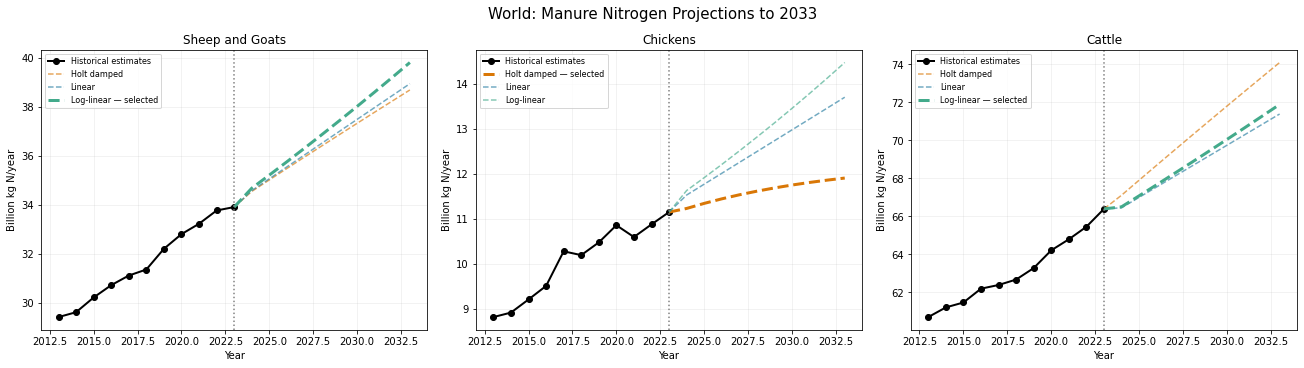

In [17]:
#plot the forecasts
colors = {
    "Linear": "#277DA1",
    "Holt damped": "#D97706",
    "Log-linear": "#43AA8B",
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(18, 5),
    constrained_layout=True,
)

for ax, animal in zip(axes, ANIMALS):
    ax.plot(
        historical.index,
        historical[animal],
        color="black",
        marker="o",
        label="Historical estimates",
        linewidth=2,
    )

    animal_forecasts = forecasts[
        forecasts["Animal"].eq(animal)
    ]

    for model_name, model_data in animal_forecasts.groupby("Model"):
        model_data = model_data.sort_values("Year")
        is_selected = model_name == best_models[animal]

        years = np.r_[2023, model_data["Year"].to_numpy()]
        values = np.r_[
            historical.loc[2023, animal],
            model_data["Nitrogen (billion kg N)"].to_numpy(),
        ]

        ax.plot(
            years,
            values,
            color=colors[model_name],
            linestyle="--",
            linewidth=3 if is_selected else 1.5,
            alpha=1 if is_selected else 0.65,
            label=model_name + (" — selected" if is_selected else ""),
        )

    ax.axvline(2023, color="gray", linestyle=":")
    ax.set_title(animal)
    ax.set_xlabel("Year")
    ax.set_ylabel("Billion kg N/year")
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)

fig.suptitle(
    f"{AREA}: Manure Nitrogen Projections to 2033",
    fontsize=15,
)

plt.show()